# Restricted Boltzmann Machines
## -- unbounded continuous visible units following Gaussian distribution

Kai Zhang and Sora Sakai, Department of Chemistry and Biochemistry, The University of Texas at Tyler, 2025

__References__:

MNIST dataset

1. http://yann.lecun.com/

2. https://www.nist.gov/itl/products-and-services/emnist-dataset

CIFAR-10 dataset

3. https://www.cs.toronto.edu/~kriz/cifar.html

STL10 dataset

4. https://ai.stanford.edu/~acoates/stl10/


**Optimal or close-to-optimal training hyperparameters**:

| dataset |split| n_hidden | n_epochs | lr (learning rate) |  CD or PCD| $k$ (MC steps)| update| generation| comments|
|:------|:-------:|:--------:|:-------:|:---------:|:-------:|:------:| :-----: |:---:|:---:|
|MNIST (unbinarized) | training |512    | 100    | 0.001        | CD | 10  |Gibbs| $k>100$ bad||
|MNIST (unbinarized) | training |512    | 100    | 0.001        | PCD | 10  | Gibbs |$k\sim 1000$ bad |
|MNIST (unbinarized) | training |512    | 100    | 0.001        | PCD | 10  |Langevin (0.05) |$k\sim 1000$ OK |CD not work,$k=100$ no help, $z\to -5$ (small variance); 1-step Langevin update is much better than Gibbs reconstruction, but it is not reconstruction|
|MNIST (unbinarized) | training |1024    | 100    | 0.01        | N/A | N/A  |SM |$k>1$ bad| Unstable|
|MNIST (unbinarized) | training |1024    | 100    | 0.001        | N/A | N/A  |SM |$k>10$ bad| |
|MNIST (unbinarized) | training |1024    | 1000    | 0.0001        | N/A | N/A  |SM |$k>100$ bad| |
|MNIST (unbinarized) | training |1024    | 5000    | 0.00001        | N/A | N/A  |SM |$k>100$ bad| E_data: -4392.3811, E_model: -5830.0009, E_diff: -1437.6198, loss: -95372.2120, mse: 0.0056. weight decay(W: 1e-4 z: 1e-5)z clamped -5|
|CIFAR-10 | training |1024    | 100    | 0.001        | CD | 10  | |$k \sim 100$ bad ||
|CIFAR-10 | training |1024    | 500    | 0.0001        | PCD | 10  | |$k \sim 100$ better ||
|CIFAR-10 | training |1024    | 100    | 0.001        | PCD | 10  | Langevin (0.05)|$k \sim 1000$ bad ||
|CIFAR-10 | training |1024    | 500    | 0.0001        | PCD | 10  | Langevin (0.05)|$k \sim 1000$ same |better E_diff|
|STL10 | unlabeled | 1024   | 500    |    0.0001     | PCD | 10  |Gibbs| $k\sim 1000$ ||
|STL10 | unlabeled | 1024   | 500    |    0.0001     | PCD | 10  |Langevin (0.05)| $k\sim 1000$ ||



You do not need to explicitly force the Gaussian RBM to keep generated visible units in $[0,1]$. Clamping destroys the Gaussian sampling assumption and ruins learning. A Gaussian RBM naturally generates real-valued data, and it is normal for reconstructions to go a bit outside the input range. Before training, the data values should be in a reasonable continuous range: either normalized within $[0,1]$ or rescaled to mean $0$ and variance $1$. After training, you may clamp for visualization by 
```python 
v_img = v_recon.clamp(0, 1)
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# check Pytorch GPU usage
# define device to be GPU if available

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU device name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device count: 1
GPU device name: NVIDIA GeForce RTX 4090


# 1. Datasets -- use one of the three example datasets
## 1.1 Load MNIST dataset from torchvision

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # Flatten 28x28 -> 784
    #transforms.Lambda(lambda x: torch.round(x)) # binarize decimals to 0,1
])

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
print(train_data.data.size(),train_data.targets.size())
print(test_data.data.size(),test_data.targets.size())

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=False) # watch out PCD last batch size matching problem
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


## 1.2 Load CIFAR10 dataset from torchvision

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html

https://docs.pytorch.org/vision/0.9/datasets.html#cifar

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # Flatten 32x32 -> 1024
])

# 170M
cifar_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
print("Train images:", len(cifar_train))
print("Test images:", len(cifar_test))

train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True)
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=True)

Train images: 50000
Test images: 10000


In [87]:
X_batch, y_batch = next(iter(test_loader))
print(X_batch.shape)

torch.Size([64, 1024])


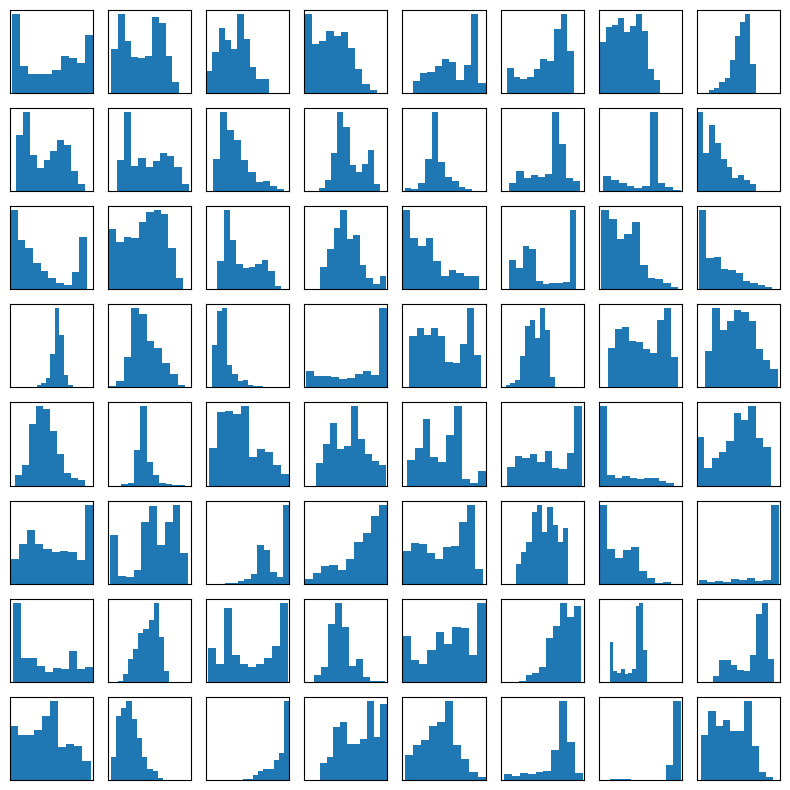

In [88]:
# see pixel distributions
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):   # 8 × 8
    ax = fig.add_subplot(8, 8, i + 1)
    ax.hist(X_batch[i].cpu().view(-1)) 
    ax.set_xlim(0,1)
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

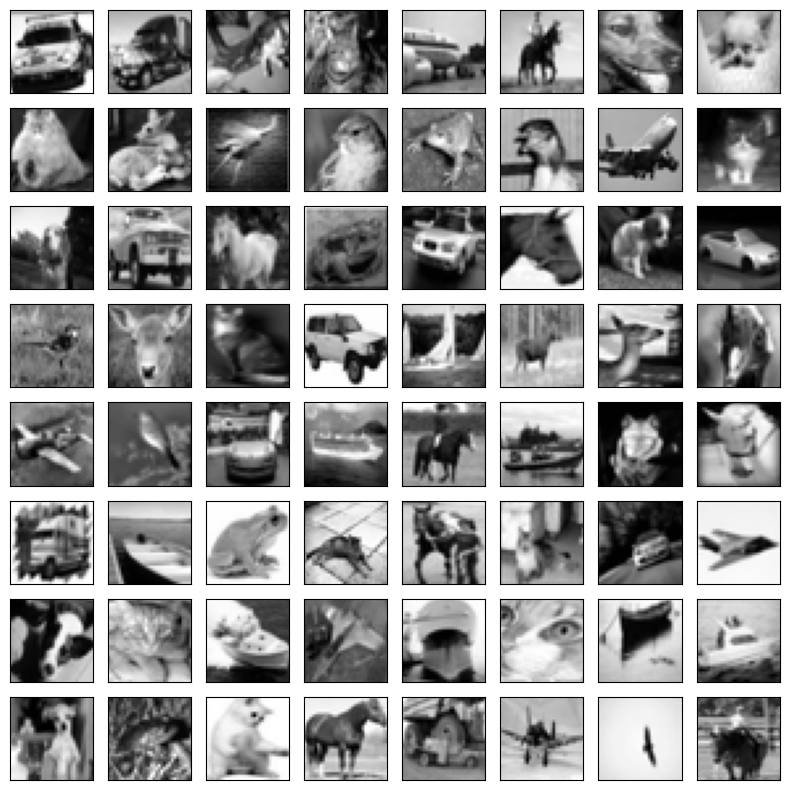

In [89]:
# see sample images
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):   # 8 × 8
    ax = fig.add_subplot(8, 8, i + 1)
    ax.imshow(X_batch[i].cpu().view(32, 32), cmap="gray")
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

## 1.3 Load STL-10 dataset from torchvision

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.STL10.html

In [148]:
# Transform: convert to tensor and normalize to [0,1]
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # convert to grayscale
    transforms.Resize((32, 32), interpolation=transforms.InterpolationMode.BILINEAR), # downsampling reduce size from 96x96 to 32x32
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),  # Flatten 32x32 -> 1024
])

# ~3G
stl10_train = datasets.STL10(root="./data", split='train', download=True, transform=transform) 
stl10_test = datasets.STL10(root="./data", split='test', download=True, transform=transform) 
stl10_unlabeled = datasets.STL10(root="./data", split='unlabeled', download=True, transform=transform)

print("Train images:", len(stl10_train))
print("Test images:", len(stl10_test))
print("Unlabeled images:", len(stl10_unlabeled))

train_loader = DataLoader(stl10_train, batch_size=64, shuffle=True, drop_last=False) # watch out PCD last batch size matching problem
test_loader = DataLoader(stl10_test, batch_size=64, shuffle=True, drop_last=False) # # y = 0-9
unlabeled_loader = DataLoader(stl10_unlabeled, batch_size=64, shuffle=True, drop_last=False) # y = -1


Train images: 5000
Test images: 8000
Unlabeled images: 100000


In [149]:
X_batch, y_batch = next(iter(test_loader))
print(X_batch.shape)

torch.Size([64, 1024])


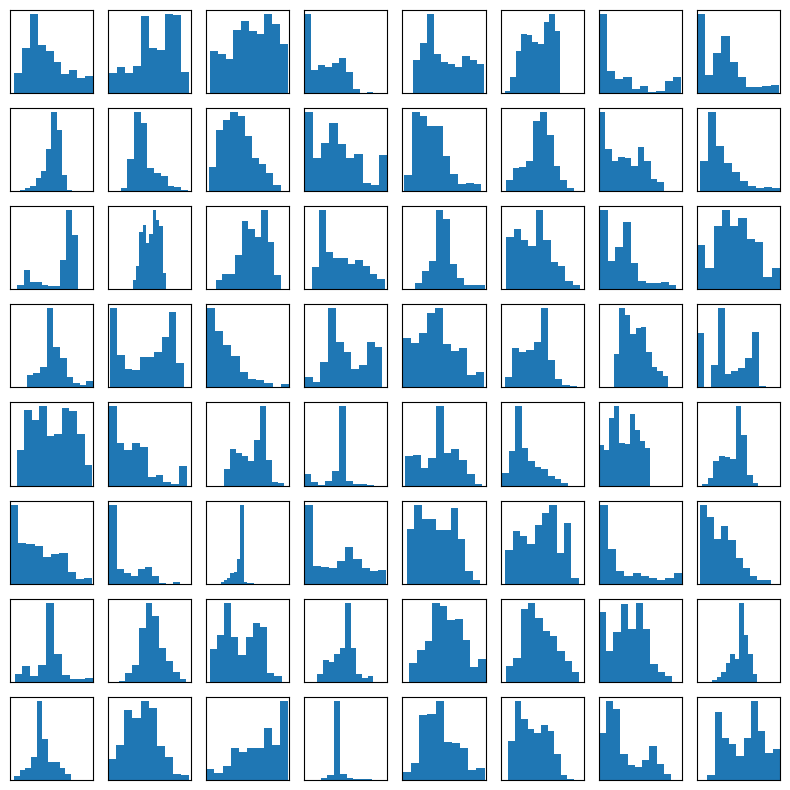

In [150]:
# see pixel distributions
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):   # 8 × 8
    ax = fig.add_subplot(8, 8, i + 1)
    ax.hist(X_batch[i].cpu().view(-1)) 
    ax.set_xlim(0,1)
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

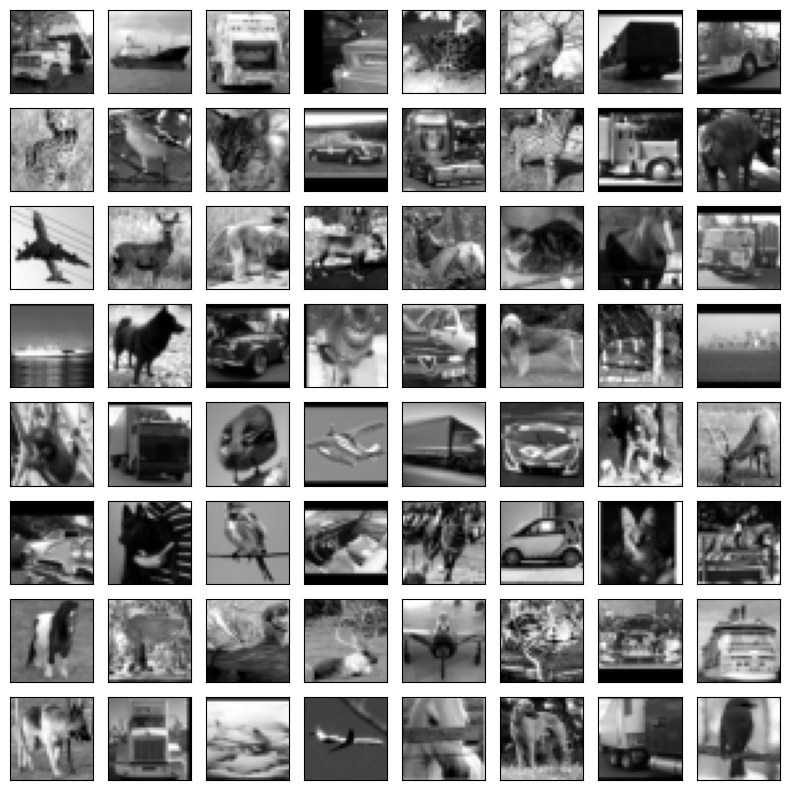

In [151]:
# see sample images
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):   # 8 × 8
    ax = fig.add_subplot(8, 8, i + 1)
    ax.imshow(X_batch[i].cpu().view(32, 32), cmap="gray")
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

# 2. Define RBM with Gaussian visible units

In [4]:
class RBM_Gaussian(nn.Module):
    """
    RBM with Gaussian visible units and binary hidden units
    variance parameter sigma_j is set to 1
    parameters: W, b, c
    learning with Markov Chain Monte Carlo methods
    CD-k or PCD-k 
    update parameters for one batch
    calculate data visible energy and model visible energy
    difference between data and model visible energies
    one-step reconstruction mse
    """
    def __init__(self, n_visible, n_hidden):
        super(RBM_Gaussian, self).__init__()
        self.n_visible = n_visible # nv
        self.n_hidden = n_hidden # nh

        # Model parameters
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01) # (nh, nv)
        self.v_bias = nn.Parameter(torch.zeros(n_visible))  # (nv, )
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))   # (nh, )

        #self.sigma2 = torch.ones(n_visible) # self.sigma2 = torch.exp(self.z)
        self.z = nn.Parameter(torch.zeros(n_visible)) # self.z = torch.log(self.sigma2)

        # Initialize persistent chain
        self.persistent_v = None

    def alpha(self, v):
        """
        v^T/sigma2^T W^T + c  
        input_shape: [batch_size, nv]
        output shape: [batch_size, nh]
        """
        return F.linear(v*torch.exp(-self.z), self.W, self.h_bias)
    
    def beta(self, h):
        """
        mean of Gaussian unit
        h^TW + b
        input_shape: [batch_size, nh]
        output shape: [batch_size, nv]
        """
        return F.linear(h, self.W.t(), self.v_bias)
        
    def bernoulli_sampling(self, p):
        """Sampling from a Bernoulli distribution with prob p."""
        return torch.bernoulli(p) #.clamp(0.0, 1.0)

    def v_to_h(self, v):
        """
        Compute p(h|v) = sigmoid(Wv + c)
        and sample v -> h
        input_shape: [batch_size, nv]
        output shape: [batch_size, nh]
        """
        p_h = torch.sigmoid(self.alpha(v))
        return self.bernoulli_sampling(p_h)

    def h_to_v(self, h):
        """
        Compute mean = h^TW + b
        and sample h -> v with Gaussian N(v|mean, sigma^2) 
        input_shape: [batch_size, nh]
        output shape: [batch_size, nv]
        """
        mean_v = self.beta(h)
        return mean_v + torch.randn_like(mean_v)*torch.exp(self.z/2.)

    def langevin_update(self, v, epsilon=0.1):
        """
        One Langevin step: v(t+1) = v(t) - epsilon^2/2 * dE/dv + epsilon*noise
        """
        v = v.view(-1, self.n_visible) # [batch_size, nv]
       
        # if to use auto_diff
        v = v.detach().clone().requires_grad_(True)
        E = self.visible_energy(v).sum()
        grad_v = torch.autograd.grad(E, v)[0] # dE/dv

        # if to calculate gradient dE/dv manually
        #grad_v = torch.exp(-self.z.t()) * (v-self.v_bias.t() - torch.sigmoid(self.alpha(v))@self.W) # [batch_size, nv]
        
        # Gaussian noise
        noise = torch.randn_like(v) # [batch_size, nv]

        # Langevin update
        v_new = v - epsilon**2/2. * grad_v + epsilon * noise

        # keep within (0,1)?
        #v_new = torch.clamp(v_new, 0.0, 1.0)
        return v_new #torch.sigmoid(v_new).detach()
        
    def forward(self, v, mc='gibbs', k=1, epsilon=0.1):
        """
        Performs k-step Gibbs sampling v->h->v' or
        k-step Langevin dynamics sampling v->v'
        """
        v = v.view(-1, self.n_visible) # [batch_size, nv]
      
        if mc == 'gibbs':
            with torch.no_grad(): # Gibbs does not need to do auto_diff
                for _ in range(k):
                    h = self.v_to_h(v)
                    v = self.h_to_v(h)
                    
        elif mc == 'langevin': # Langevin MUST keep autograd to use it
            for _ in range(k):
                v = self.langevin_update(v, epsilon)
            #v = self.bernoulli_sampling(v.detach())
                    
        return v #.detach()   

    def visible_energy(self, v):
        """Compute the visible energy E(v)."""
        vbias_term = torch.sum((v - self.v_bias)**2/2.0*torch.exp(-self.z), dim=1) # [batch_size, 1]
        wxv_c = self.alpha(v) # Wv + c: [batch_size, nh]
        hidden_term = torch.sum(F.softplus(wxv_c), dim=1) # [batch_size, 1]
        return vbias_term - hidden_term

    def contrastive_divergence(self, v0, pcd=False, mc='gibbs', k=1, epsilon=0.1, lr=0.001):
        """
        Perform gradient descent for one batch
        with k-step Contrastive Divergence 
        """
        v_batch = v0.view(-1, self.n_visible) # [batch_size, nv] 
        p_h_batch = torch.sigmoid(self.alpha(v_batch)) # [batch_size, nh]

        # Initialize persistent chain the first time
        if self.persistent_v is None:
            self.persistent_v = v_batch.detach().clone()

        # data term
        self.W.grad = -torch.matmul(p_h_batch.t(), v_batch)/v_batch.size(0) # [nh, nv]
        self.h_bias.grad = -torch.mean(p_h_batch, dim=0) # [nh]
        self.v_bias.grad = -torch.mean(v_batch, dim=0) # [nv] (v_j-b_j) but b_j will cancel
        self.z.grad = -torch.mean(torch.exp(-self.z) * ((v_batch-self.v_bias)**2/2. - (p_h_batch@self.W)*v_batch), dim=0)
    
        # Gibbs sampling
        if pcd == True: # PCD
            self.persistent_v = self.persistent_v.detach()
            v_sample = self.forward(self.persistent_v, mc, k, epsilon)  # [batch_size, nv]
            self.persistent_v = v_sample.detach().clone()           
        else: # CD
            v_sample = self.forward(v_batch, mc, k, epsilon)  # [batch_size, nv]
        
        p_h_sample= torch.sigmoid(self.alpha(v_sample)) # [batch_size, nh]

        # data term - model term
        self.W.grad -= -torch.matmul(p_h_sample.t(), v_sample)/v_sample.size(0) # [nh, nv]
        self.h_bias.grad -= -torch.mean(p_h_sample, dim=0) # [nh]
        self.v_bias.grad -= -torch.mean(v_sample, dim=0) # [nv]
        self.z.grad -= -torch.mean(torch.exp(-self.z) * ((v_sample-self.v_bias)**2/2. - (p_h_sample@self.W)*v_sample), dim=0)

        # Update parameters manually by gradient descent
        for param in [self.W, self.v_bias, self.h_bias, self.z]:
            param.data -= lr * param.grad

        self.z.data.clamp_(-5, 5) # avoid langevin updates lead to exp(-z) explode
        
        E_data = torch.mean(self.visible_energy(v_batch))
        E_model = torch.mean(self.visible_energy(v_sample))       
        E_diff = E_model - E_data 
        #loss = nn.MSELoss(reduction='mean') 
        #MSE = loss(v_sample, v_batch) 
        
        v_recon = self.forward(v_batch, mc='gibbs', k=1)
        MSE = torch.mean((v_recon.clamp(0, 1) - v_batch)**2) # clamp v' into [0,1]
        
        return E_data, E_model, E_diff, MSE

    def gamma(self, v):
        """
        v_j - b_j - sum_{i=1}^{n_h}(sigmoid(alpha_i(v))W_ij)
        input_shape: [batch_size, nv]
        output shape: [batch_size, nv]
        """
        h_mean = torch.sigmoid(self.alpha(v)) # [batch_size, nh]
        summation = h_mean @ self.W 

        return v - self.v_bias.unsqueeze(0) - summation
        
    def sigmoid2(self, x):
        sigmoid = torch.sigmoid(x)
        return sigmoid * (1 - sigmoid)
    
    def score_matching_loss(self, v):
        precision = torch.exp(-self.z) # [nv, ]

        # compute first term, (precision * gamma)^2
        score = precision * self.gamma(v) # [batch_size, nv]
        score_norm_sq = (score ** 2).sum(dim=1) # [batch_size, ]

        # second term, precision/gaussian_lap
        gaussian_lap = precision.sum() # [1, ]

        # third term, hidden_lap
        h_var = self.sigmoid2(self.alpha(v)) # [batch_size, nh]
        
        # self.W [nh, nv] @ precision [nv, ]
        W_norm_sq = (self.W ** 2) @ (precision ** 2)   # [nh, ] Σ_j W_ij² e^{-2z_j}

        # h_var [batch_size, nh] * W_norm_sq [nh, ]
        hidden_lap = (h_var * W_norm_sq).sum(dim=1) # [batch_size, ]

        loss = 0.5 * score_norm_sq - gaussian_lap + hidden_lap
        return loss.mean()

In [5]:
##### define RBM model
p = 28 # 28 for MNIST 32 for CIFAR10 and STL10
n_visible = p*p  # 28x28 or 32x32 pixels
n_hidden = 1024 # hidden units

rbm = RBM_Gaussian(n_visible, n_hidden).to(device)

# 3. Define and run the training loops

In [6]:
'''
Contrastive Divergence
'''

def train_CD(model, train_loader, pcd, mc, k, epsilon, lr, n_epochs):
    if pcd == True:
        print(f"Training with PCD and {k}-step {mc} updates")
    else:
        print(f"Training with CD and {k}-step {mc} updates")
    
    history = {"E_data": [], "E_model": [], "E_diff": [], "mse": []}

    for epoch in range(n_epochs):
        E_data_epoch, E_model_epoch, E_diff_epoch, mse_epoch = 0., 0., 0., 0.
        for batch, (X_train, _) in enumerate(train_loader):
            X_train = X_train.to(device)
            E_data, E_model, E_diff, mse = model.contrastive_divergence(X_train, pcd, mc, k, epsilon, lr)
            E_data_epoch += E_data.item()
            E_model_epoch += E_model.item()
            E_diff_epoch += E_diff.item()
            mse_epoch += mse.item()
        
        E_data_epoch /= len(train_loader)
        E_model_epoch /= len(train_loader)
        E_diff_epoch /= len(train_loader)
        mse_epoch /= len(train_loader)
        
        history["E_data"].append(E_data_epoch)
        history["E_model"].append(E_model_epoch)

        history["E_diff"].append(E_diff_epoch)
        history["mse"].append(mse_epoch)
            
        print(f"Epoch {epoch + 1}/{n_epochs}, E_data: {E_data_epoch:.4f}, E_model: {E_model_epoch:.4f}, E_diff: {E_diff_epoch:.4f}, mse: {mse_epoch:.4f}")

    return history

In [7]:
'''
Score Matching
'''

def train_SM(model, train_loader, pcd, mc, k, epsilon, lr, n_epochs):
    print("Training with score matching")
    
    history = {"E_data": [], "E_model": [], "E_diff": [], "loss": [], "mse": []}

    optimizer = torch.optim.Adam([
    {"params": [model.W], "weight_decay": 1e-4},
    {"params": [model.z], "weight_decay": 1e-5},
    {"params": [model.v_bias, model.h_bias], "weight_decay": 0.0}
], lr=lr)

    for epoch in range(n_epochs):
        E_data_epoch, E_model_epoch, E_diff_epoch, loss_epoch, mse_epoch = 0., 0., 0., 0., 0.
        for batch, (X_train, _) in enumerate(train_loader):
            v = X_train.to(device)

            # Train
            optimizer.zero_grad()
            loss = model.score_matching_loss(v)
            loss.backward()
            optimizer.step()

            model.z.data.clamp_(-5, 5)

            # Compute Energy and MSE for diagnosis
            with torch.no_grad():
                # Initialize persistent chain the first time
                if model.persistent_v is None:
                    model.persistent_v = v.detach().clone()

                # Gibbs sampling
                if pcd == True: # PCD
                    model.persistent_v = model.persistent_v.detach()
                    v_sample = model.forward(model.persistent_v, mc, k, epsilon)  # [batch_size, nv]
                    model.persistent_v = v_sample.detach().clone()           
                else: # CD
                    v_sample = model.forward(v, mc, k, epsilon)  # [batch_size, nv]

                E_data = torch.mean(model.visible_energy(v))
                E_model = torch.mean(model.visible_energy(v_sample))
                E_diff = E_model - E_data 
                
                v_recon = rbm.forward(v, mc='gibbs', k=1)
                mse = torch.mean((v_recon.clamp(0, 1) - v)**2) # clamp v' into [0,1]

            E_data_epoch += E_data.item()
            E_model_epoch += E_model.item()
            E_diff_epoch += E_diff.item()
            loss_epoch += loss.item()
            mse_epoch += mse.item()
            
        E_data_epoch /= len(train_loader)
        E_model_epoch /= len(train_loader)
        E_diff_epoch /= len(train_loader)
        loss_epoch /= len(train_loader)
        mse_epoch /= len(train_loader)
        
        history["E_data"].append(E_data_epoch)
        history["E_model"].append(E_model_epoch)
        history["E_diff"].append(E_diff_epoch)
        
        history["loss"].append(loss_epoch)
        history["mse"].append(mse_epoch)
        
        print(f"Epoch {epoch + 1}/{n_epochs}, E_data: {E_data_epoch:.4f}, E_model: {E_model_epoch:.4f}, E_diff: {E_diff_epoch:.4f}, loss: {loss_epoch:.4f}, mse: {mse_epoch:.4f}")

    return history

In [8]:
# define training hyperparameters

n_epochs = 1000
lr = 0.00001
k = 10
pcd = True
mc = 'gibbs' # gibbs or langevin
epsilon=0.05 # langevin step size

if pcd == True:
    cdtype = 'pcd'
else:
    cdtype = 'cd'

In [9]:
# training epochs
# history = train_CD(rbm, train_loader, pcd, mc, k, epsilon, lr, n_epochs)
history = train_SM(rbm, train_loader, pcd, mc, k, epsilon, lr, n_epochs)

Training with score matching
Epoch 1/1000, E_data: -699.0095, E_model: -333.7904, E_diff: 365.2191, loss: -745.3067, mse: 0.2991
Epoch 2/1000, E_data: -701.2882, E_model: -334.9742, E_diff: 366.3140, loss: -760.1768, mse: 0.2974
Epoch 3/1000, E_data: -701.2402, E_model: -334.2606, E_diff: 366.9796, loss: -772.0220, mse: 0.2947
Epoch 4/1000, E_data: -701.1912, E_model: -333.2416, E_diff: 367.9496, loss: -782.4244, mse: 0.2915
Epoch 5/1000, E_data: -701.2624, E_model: -332.1613, E_diff: 369.1010, loss: -791.7945, mse: 0.2885
Epoch 6/1000, E_data: -701.2885, E_model: -331.3335, E_diff: 369.9551, loss: -800.5214, mse: 0.2858
Epoch 7/1000, E_data: -701.0275, E_model: -330.3063, E_diff: 370.7212, loss: -808.8362, mse: 0.2835
Epoch 8/1000, E_data: -700.5538, E_model: -329.5581, E_diff: 370.9957, loss: -816.9216, mse: 0.2817
Epoch 9/1000, E_data: -700.0491, E_model: -328.7917, E_diff: 371.2574, loss: -824.8847, mse: 0.2804
Epoch 10/1000, E_data: -699.5977, E_model: -328.4186, E_diff: 371.1791,

In [27]:
# Resume Training with Score-Matching
n_epochs = 1

# history_temp = train_CD(rbm, train_loader, pcd, mc, k, epsilon, lr, n_epochs)
history_temp = train_SM(rbm, train_loader, pcd, mc, k, epsilon, lr, n_epochs)

for key in history:
    history[key].extend(history_temp[key])

n_epochs = len(history["E_data"])
print("Total epochs: ", n_epochs)

Training with score matching
Epoch 1/1, E_data: -2954.8534, E_model: -6544.5168, E_diff: -3589.6633, loss: -79092.4115, mse: 0.0096
Total epochs:  1001


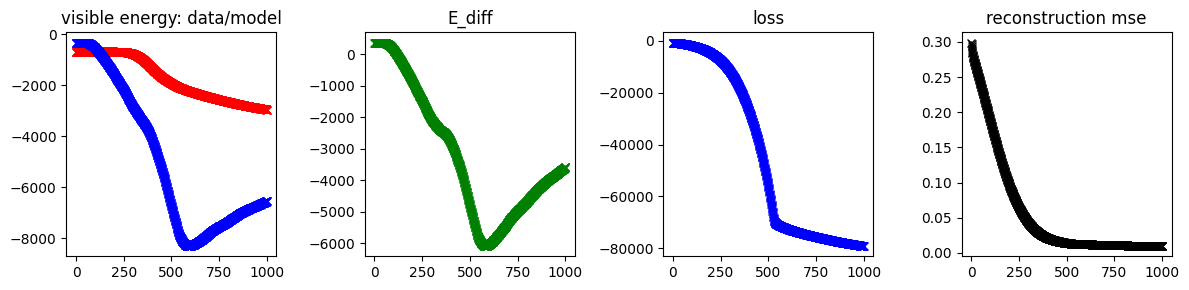

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

axes[0].plot(history["E_data"],'rx-')
axes[0].plot(history["E_model"],'bx-')

axes[1].plot(history["E_diff"],'gx-')
axes[2].plot(history["loss"],'bx-')
axes[3].plot(history["mse"],'kx-')

axes[0].set_title('visible energy: data/model')
axes[1].set_title('E_diff')
axes[2].set_title('loss')
axes[3].set_title('reconstruction mse')

plt.tight_layout()
plt.show()

#fig.savefig('./GRBMtraining_nh{}{}-{}{}_lr{}.png'.format(n_hidden,cdtype,k,mc,lr), dpi = 600, bbox_inches='tight')


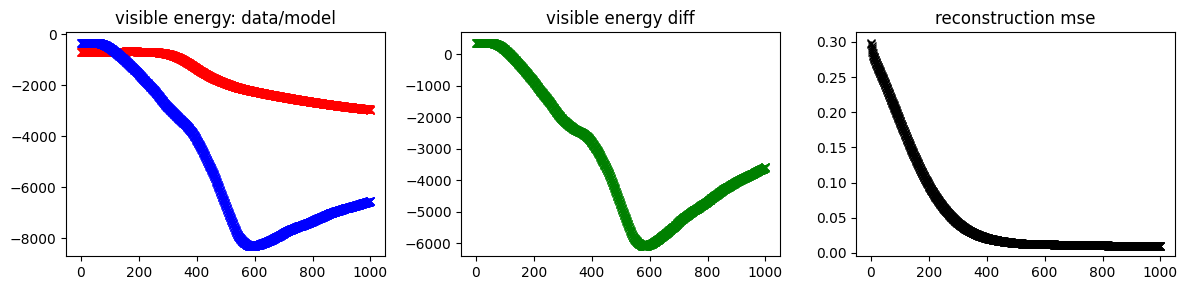

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

axes[0].plot(history["E_data"],'rx-')
axes[0].plot(history["E_model"],'bx-')

axes[1].plot(history["E_diff"],'gx-')
axes[2].plot(history["mse"],'kx-')

axes[0].set_title('visible energy: data/model')
axes[1].set_title('visible energy diff')
axes[2].set_title('reconstruction mse')

plt.tight_layout()
plt.show()

#fig.savefig('./GRBMtraining_nh{}{}-{}{}_lr{}.png'.format(n_hidden,cdtype,k,mc,lr), dpi = 600, bbox_inches='tight')


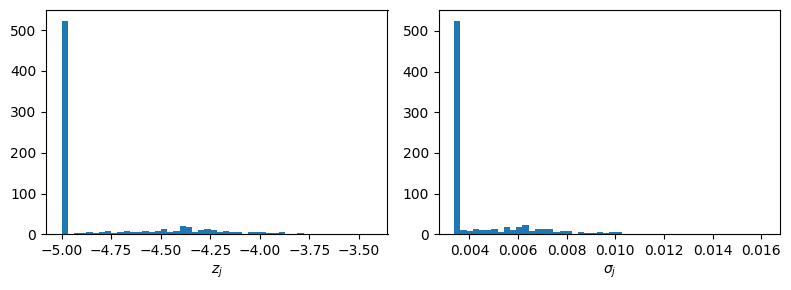

In [30]:
# check histogram of parameter z and standard deviation sigma
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

axes[0].hist(rbm.z.data.cpu(),bins=50)
axes[1].hist(torch.exp(rbm.z.data.cpu())/2.,bins=50)

axes[0].set_xlabel('$z_j$')
axes[1].set_xlabel(r'$\sigma_j$')

plt.tight_layout()
plt.show()

# 4. Optional saving and reloading steps

## (4.1) Save model parameters and training results

In [31]:
# save parameters as numpy array files
for name, param in rbm.state_dict().items():
    print('parameter:', name, param.size())
    np.save(f"{name}.npy", param.cpu().numpy())

np.save(f"./training_nh{n_hidden}{cdtype}-{k}{mc}_lr{lr}.npy", history, allow_pickle=True) # save a list of dictionary

parameter: W torch.Size([1024, 784])
parameter: v_bias torch.Size([784])
parameter: h_bias torch.Size([1024])
parameter: z torch.Size([784])


## (4.2) Reload parameters or training results

In [32]:
################################################
# To load parameters from npy file
################################################
state_dict = rbm.state_dict()   # get a copy of current state dict
for name in state_dict.keys():
    param = np.load(name + ".npy")
    state_dict[name] = torch.tensor(param)
rbm.load_state_dict(state_dict) # this actually loads the parameters

training_history = np.load(f"./training_nh{n_hidden}{cdtype}-{k}{mc}_lr{lr}.npy", allow_pickle=True).tolist() # a list of dictionary

# 5. Reconstruction test

In [33]:
X_test, _ = next(iter(test_loader))
#X_test = X_test[:10].round().to(device)

In [34]:
X_recon = rbm.forward(X_test.to(device), mc='gibbs', k=100, epsilon=epsilon).detach() # langevin update is not reconstruction by definition
X_recon = X_recon.clamp(0,1)

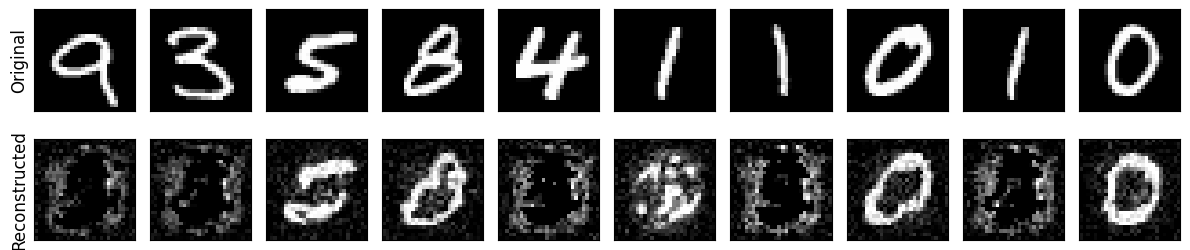

In [35]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(X_test[i].cpu().view(p, p), cmap="grey")
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(X_recon[i].cpu().view(p, p), cmap="gray")
    #axes[1, i].axis("off")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.tight_layout()
plt.show()

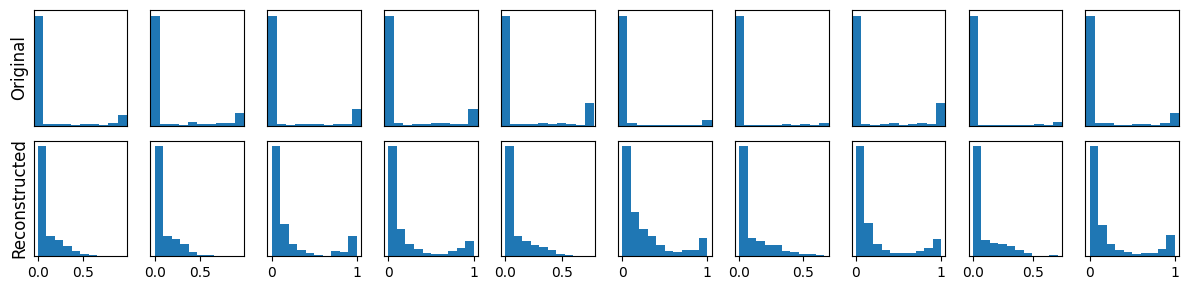

In [36]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(X_test[i].cpu().view(-1)) 
    axes[0, i].set_xlim(0,1)
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(X_recon[i].cpu().view(-1)) 
    #axes[1, i].axis("off")
    #axes[1, i].set_xticks([])
    #axes[1, i].set_xlim(0,1)
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.tight_layout()
plt.show()

## (optional) Check hidden unit histogram

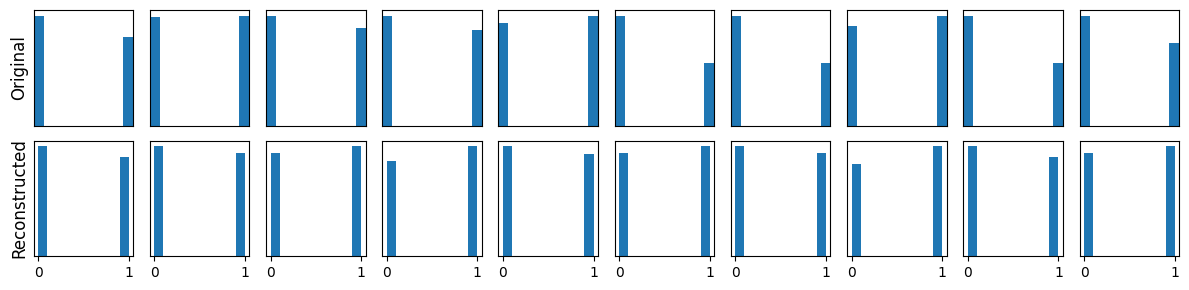

In [37]:
h_test = rbm.v_to_h(X_test.to(device)).detach() 
h_recon = rbm.v_to_h(X_recon.to(device)).detach()

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(h_test[i].cpu().view(-1)) 
    axes[0, i].set_xlim(0,1)
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(h_recon[i].cpu().view(-1)) 
    #axes[1, i].axis("off")
    #axes[1, i].set_xticks([])
    #axes[1, i].set_xlim(0,1)
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.tight_layout()
plt.show()

# 6.  Generation from random start

It is easier to generate from random binary ${\bf h}_0$ to initialize a valid starting visible units ${\bf h}_0 \to {\bf v}_0$.

In [38]:
n_sample = 256

ph = 0.5 # Bernoulli probability
h0 = torch.bernoulli(torch.ones(n_sample, n_hidden)*ph).float().to(device) # bernoulli 0,1 with probability ph
X0 = rbm.h_to_v(h0)

#X0 = torch.rand((n_sample, n_visible),requires_grad=False).float().to(device) # uniform [0,1]
#X0 = torch.randint(1, (n_sample, n_visible),requires_grad=False).float().to(device) # uniform binary 0,1
#X0 = torch.bernoulli(torch.ones(n_sample, n_visible)*0.3).float().to(device) # bernoulli 0,1 with probability
#X0 = (0.1+0.1*torch.randn((n_sample, n_visible),requires_grad=False)).clamp(0,1).float().to(device)

with torch.no_grad(): # no graph, avoid GPU memory growth
    X_gen = rbm.forward(X0, mc='gibbs', k=1000, epsilon=epsilon).detach() # gibbs or manual diff langevin does not need graph

#X_gen = rbm.forward(X0, mc='langevin', k=1000, epsilon=epsilon).detach() #langevin autodiff must use graph, GPU memory cautious

X_gen = X_gen.clamp(0,1)    

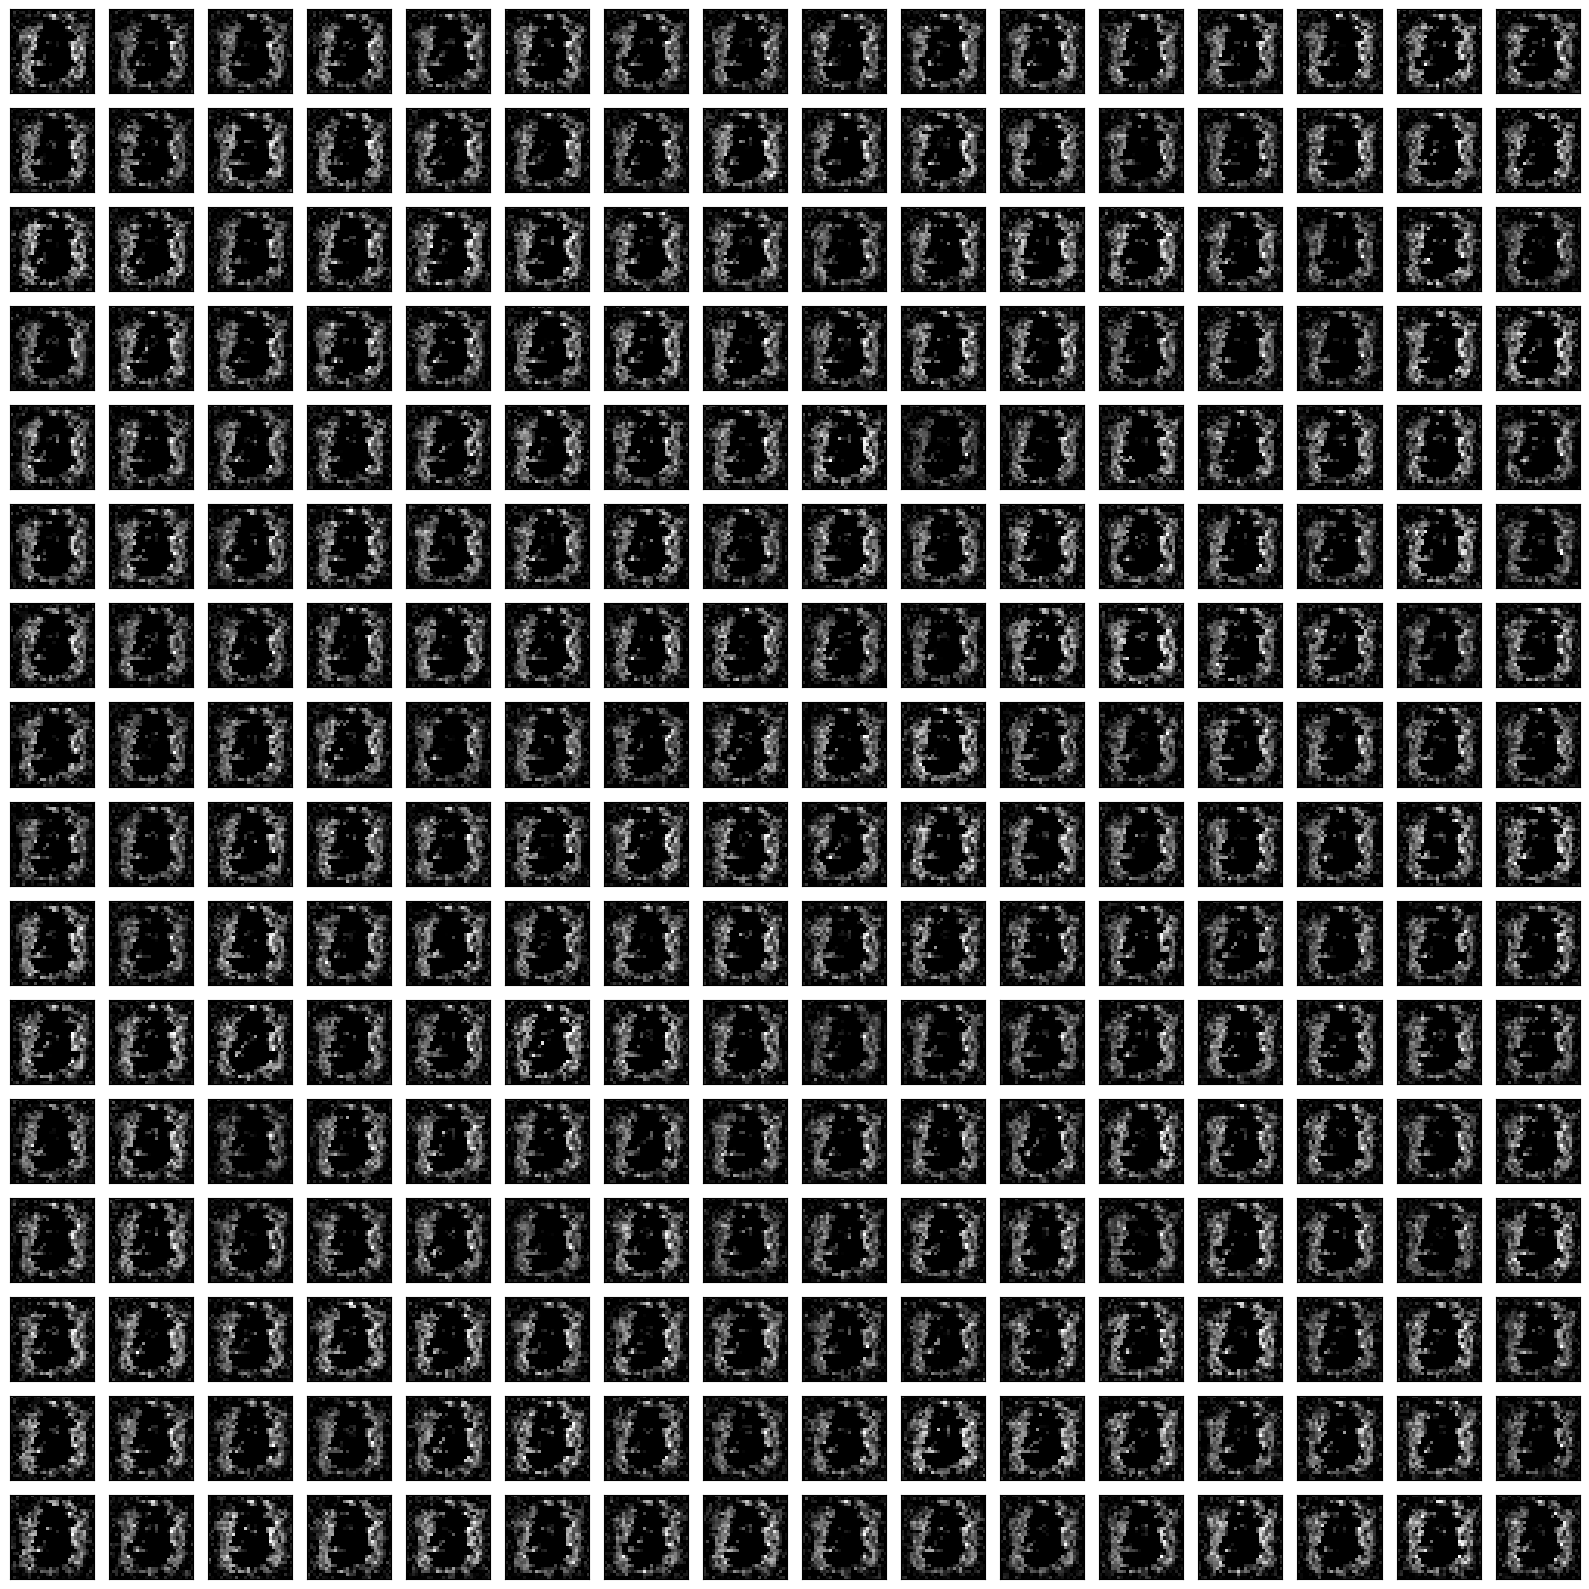

In [39]:
fig = plt.figure(figsize=(16, 16)) 
for i in range(256):   # 16 × 16
    ax = fig.add_subplot(16, 16, i + 1)
    ax.imshow(X_gen[i].cpu().view(p, p), cmap="gray")
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

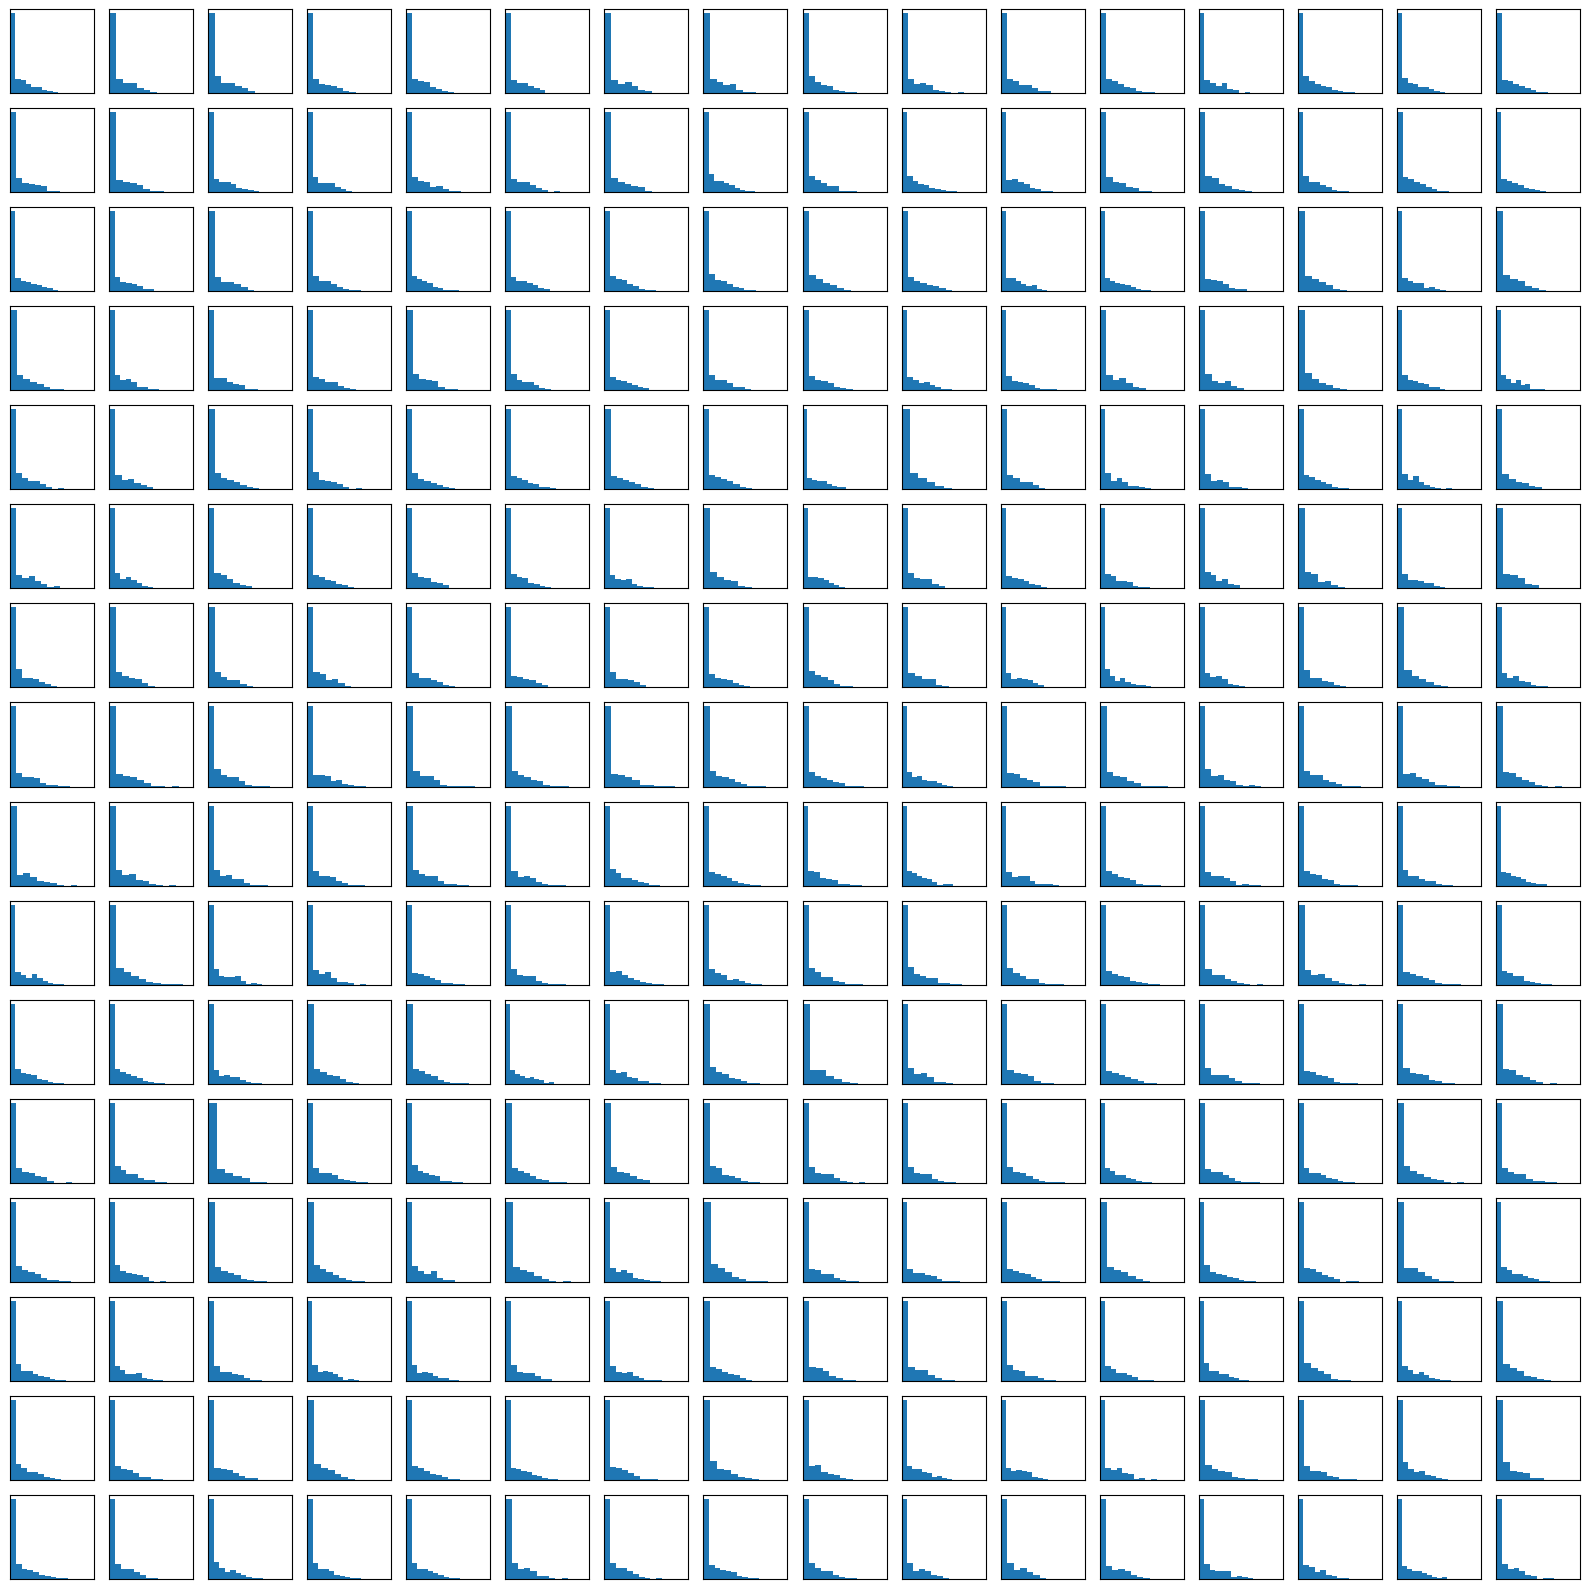

In [40]:
fig = plt.figure(figsize=(16, 16)) 
for i in range(256):   # 16 × 16
    ax = fig.add_subplot(16, 16, i + 1)
    ax.hist(X_gen[i].cpu().view(-1)) 
    #ax.axis('off')
    ax.set_xlim(0,1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

## (optional) Check hidden unit histogram

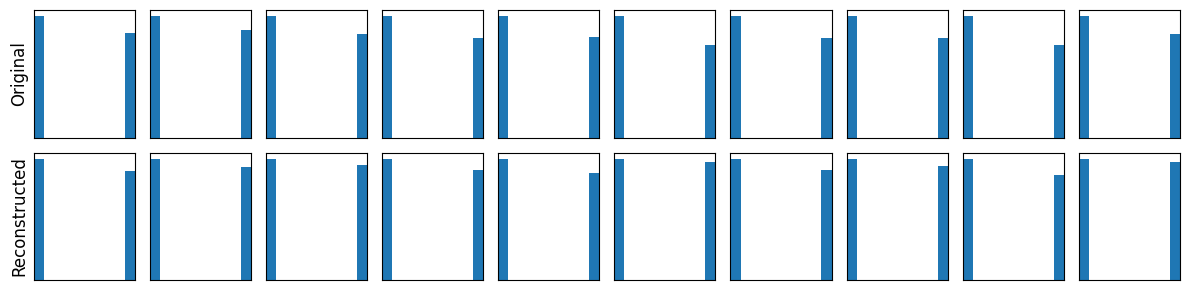

In [41]:
h0 = rbm.v_to_h(X0.to(device)).detach() 
h_gen = rbm.v_to_h(X_gen.to(device)).detach() 

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(h0[i].cpu().view(-1)) 
    axes[0, i].set_xlim(0,1)
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(h_gen[i].cpu().view(-1)) 
    #axes[1, i].axis("off")
    axes[1, i].set_xticks([])
    axes[1, i].set_xlim(0,1)
    axes[1, i].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.tight_layout()
plt.show()

## (optional) Check PCD persistent v batch


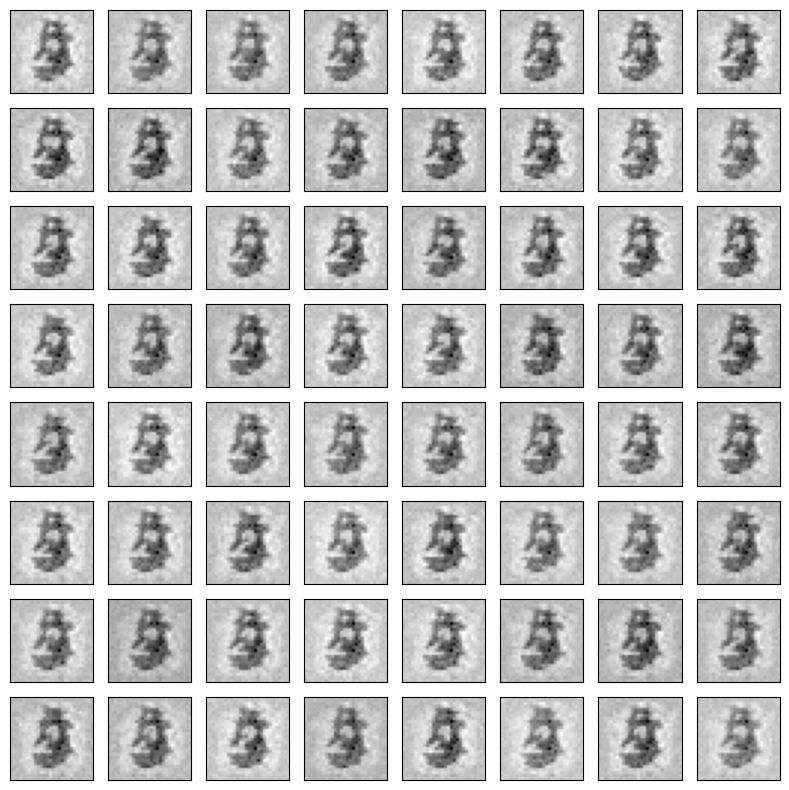

In [42]:
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):   # 8 × 8
    ax = fig.add_subplot(8, 8, i + 1)
    ax.imshow(rbm.persistent_v[i].cpu().view(p, p), cmap="grey")
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)

plt.show()

# 7. Plot weight matrix W as filters (row vectors folded)

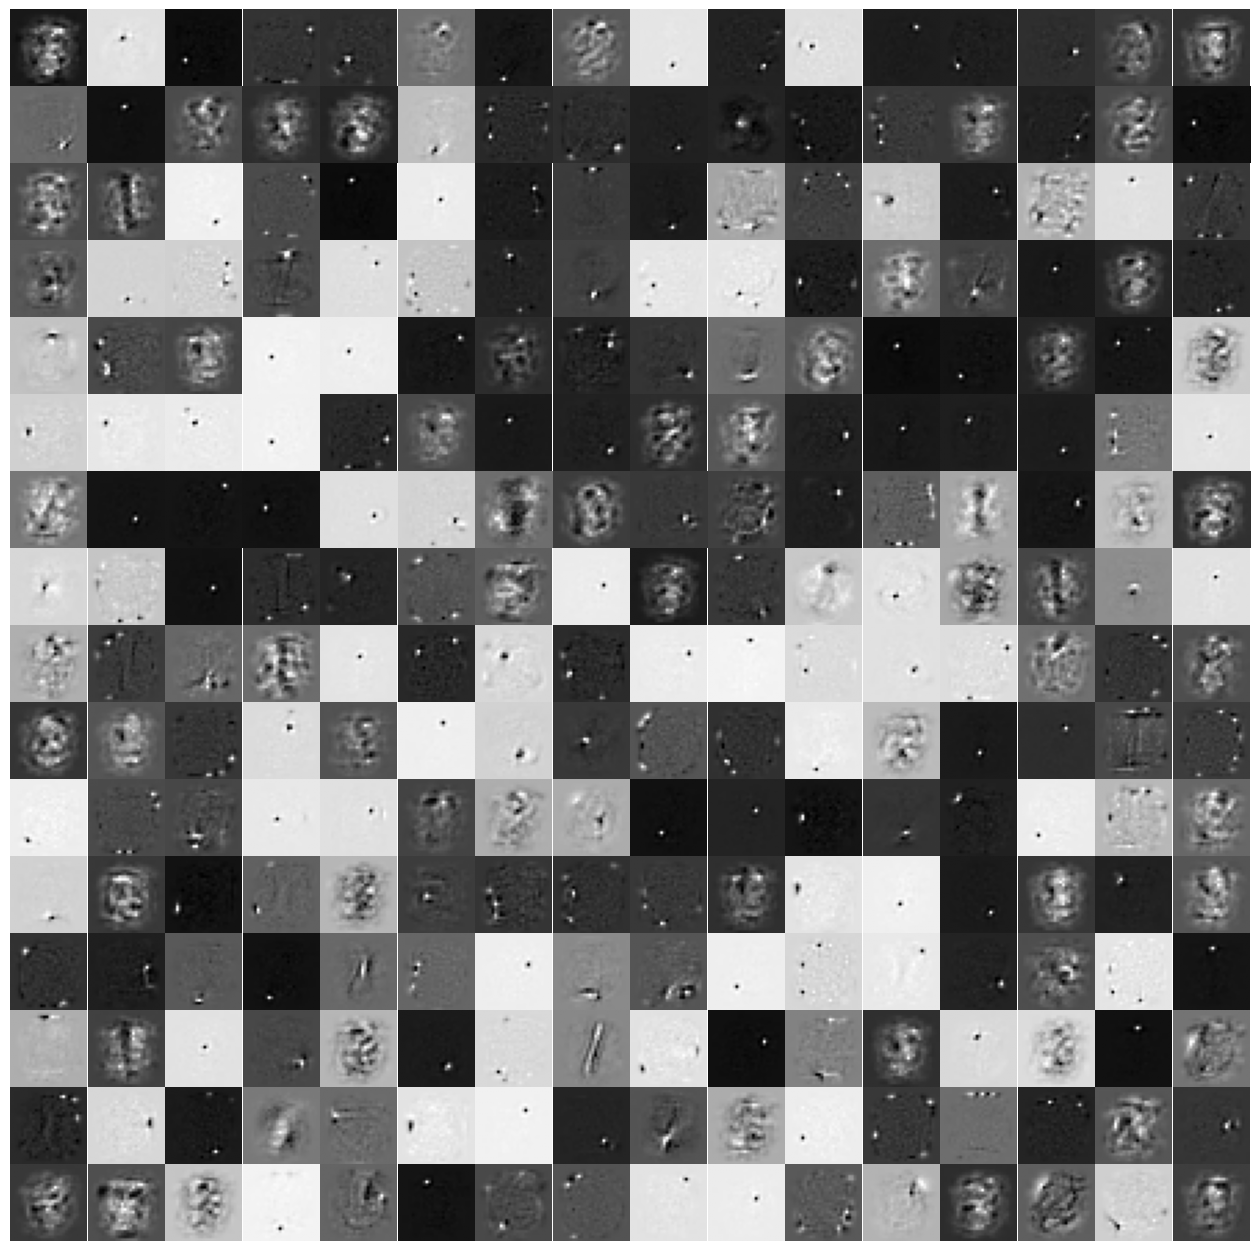

In [43]:
fig = plt.figure(figsize=(16, 16)) 
for i in range(256):   # 16 × 16
    ax = fig.add_subplot(16, 16, i + 1)
    ax.imshow(rbm.W[i].detach().cpu().view(p, p), cmap="gray")
    ax.axis('off')
#plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.margins(0, 0)
#cbar = fig.colorbar(im, orientation='horizontal') #, fraction=0.05, pad=0.02)

plt.show()

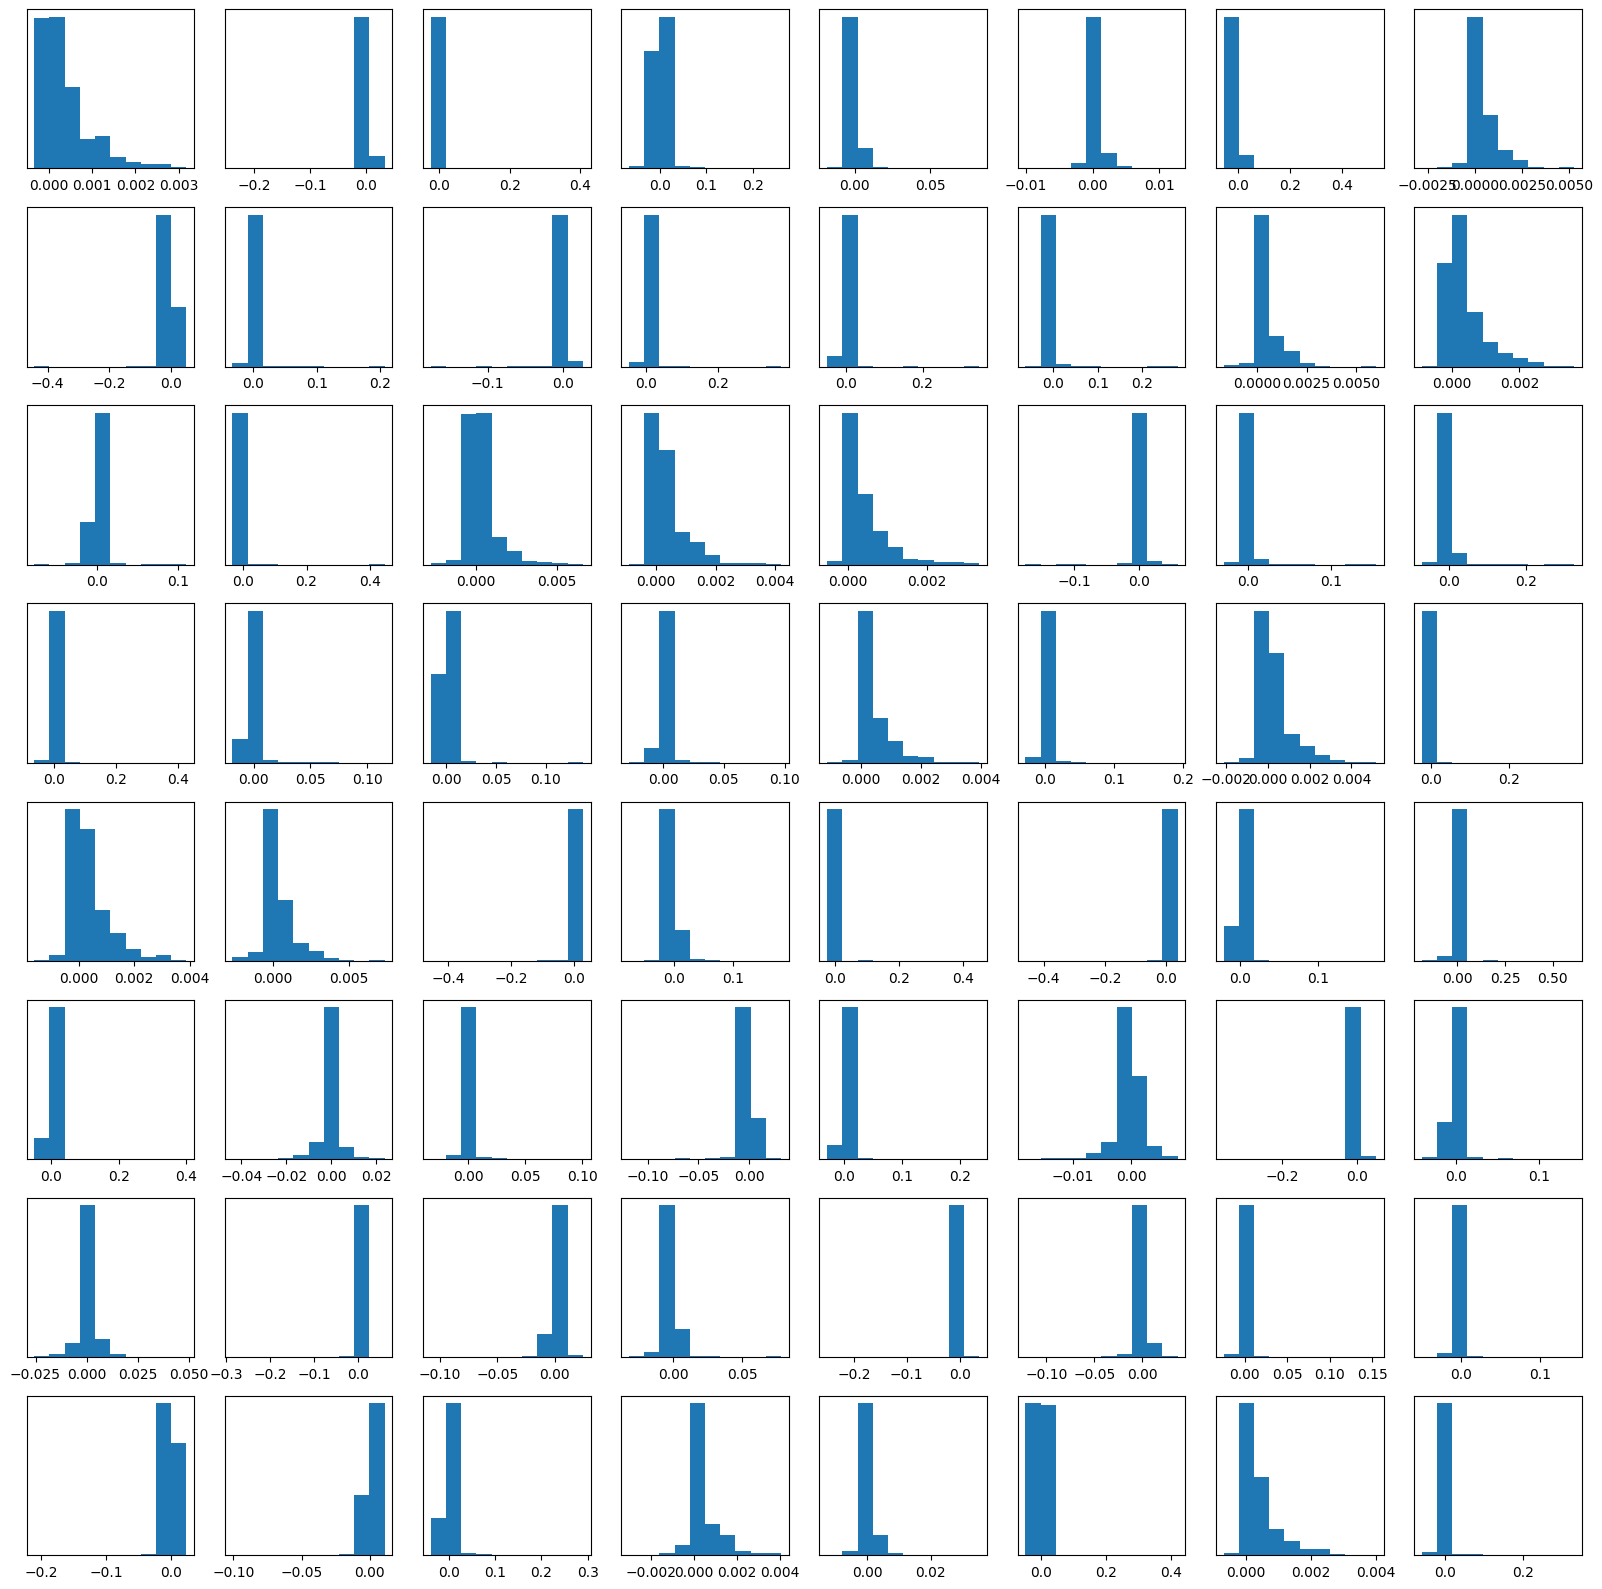

In [44]:
fig = plt.figure(figsize=(16, 16)) 
for i in range(64):   # 16 × 16
    ax = fig.add_subplot(8, 8, i + 1)
    ax.hist(rbm.W[i].detach().cpu().view(-1))
    #ax.axis('off')
    #ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
#plt.subplots_adjust(wspace=0, hspace=0)
#plt.margins(0, 0)
#cbar = fig.colorbar(im, orientation='horizontal') #, fraction=0.05, pad=0.02)

plt.show()

# The End